<a href="https://colab.research.google.com/github/RafaelaMlucca/AnaliseViolMulher/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Violência contra a Mulher no SINAN (2020-2024)

**Projeto:** Assinaturas preditivas dos tipos de violência contra a mulher  
**Autora:** Rafaela Lucca


## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visual mais agradável
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

# Pasta dos dados
DRIVE = Path('/content/drive/MyDrive/projeto_violencia_mulher')

# Carrega a base
df = pd.read_parquet(DRIVE / 'viol_mulher.parquet')
print(f'Base carregada: {df.shape}')

Base carregada: (1677888, 57)


---

# 1. Visão Geral

Primeira impressão da base: tamanho, tipos, ausentes.

In [3]:
df.head()

,NU_ANO,SG_UF_NOT,TPUNINOT,DT_NOTIFIC,DT_OCOR,CS_SEXO,NU_IDADE_N,CS_RACA,CS_ESCOL_N,CS_GESTANT,...,REL_EXNAM,REL_FILHO,REL_IRMAO,REL_CONHEC,REL_DESCO,REL_CUIDA,REL_PATRAO,y_fisic,y_psico,y_sexu
0,,35,,20200310,20200310,F,4020,1,05,1,...,2,2,2,2,2,2,2,1.0,0.0,0.0
1,,35,,20200321,20200321,F,4032,4,06,5,...,2,2,2,2,2,2,2,1.0,0.0,0.0
2,,35,,20200328,20200328,F,4012,1,09,5,...,2,2,2,1,2,2,2,1.0,0.0,0.0
3,,35,,20200402,20200401,F,4032,1,05,9,...,2,2,2,2,2,2,2,1.0,0.0,0.0
4,,35,,20200402,20200402,F,4002,1,10,6,...,2,2,2,2,2,2,2,1.0,0.0,0.0


In [ ]:
df.info()

In [4]:
# Quantos % de NaN por coluna?
ausentes = (df.isna().mean() * 100).sort_values(ascending=False).round(1)
ausentes.head(20)

,0
y_sexu,2.4
y_psico,2.4
y_fisic,1.3
SG_UF_NOT,0.0
DT_OCOR,0.0
CS_SEXO,0.0
TPUNINOT,0.0
DT_NOTIFIC,0.0
NU_ANO,0.0
CS_GESTANT,0.0


---

# 2. Vítima

Quem são as mulheres notificadas?

### 2.1 Idade

In [6]:
# A idade está codificada em NU_IDADE_N: prefixo (1=h, 2=d, 3=m, 4=ano) + valor
# Ex.: '4018' = 18 anos. Vamos converter.
def idade_em_anos(codigo):
    if pd.isna(codigo):
        return np.nan
    s = str(codigo).zfill(4)
    if s[0] == '4':
        return int(s[1:])
    elif s[0] in ('1', '2', '3'):
        return 0  # menores de 1 ano
    return np.nan

df['IDADE'] = df['NU_IDADE_N'].apply(idade_em_anos)
df['IDADE'].describe()

,IDADE
count,1.674618e+06
mean,2.832479e+01
std,1.712315e+01
min,0.000000e+00
25%,1.600000e+01
50%,2.600000e+01
75%,3.800000e+01
max,1.300000e+02


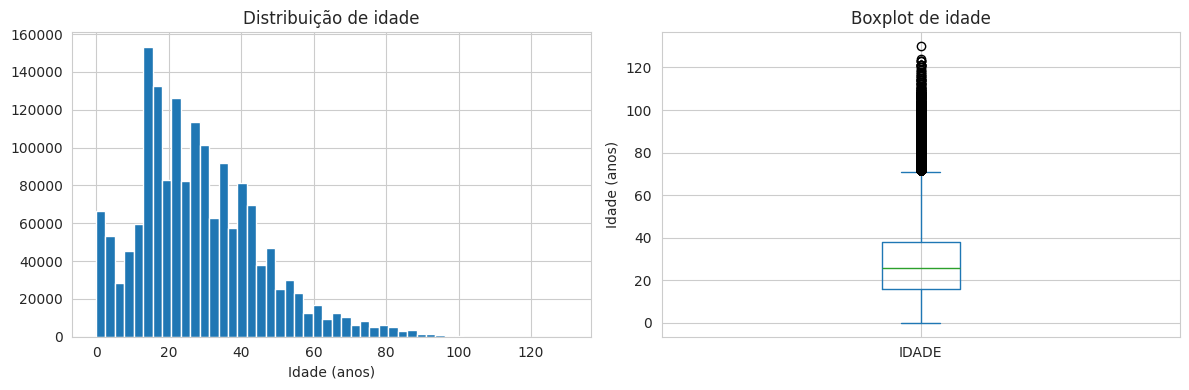

In [7]:
# Histograma de idade
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['IDADE'].hist(bins=50)
plt.title('Distribuição de idade')
plt.xlabel('Idade (anos)')

plt.subplot(1, 2, 2)
df['IDADE'].plot(kind='box')
plt.title('Boxplot de idade')
plt.ylabel('Idade (anos)')
plt.tight_layout()
plt.show()

In [8]:
# Quantas vítimas por faixa etária?
faixas = pd.cut(df['IDADE'], bins=[0, 9, 14, 19, 29, 39, 49, 59, 110],
                labels=['0-9', '10-14', '15-19', '20-29', '30-39',
                        '40-49', '50-59', '60+'])
faixas.value_counts().sort_index()

,count
IDADE,
0-9,148634
10-14,181086
15-19,221985
20-29,398695
30-39,306343
40-49,208370
50-59,90970
60+,90410


**O que olhar aqui:**
- Há vítimas com idade > 110? (provável ruído)
- Quantas crianças (0-9)? Vamos manter ou filtrar?
- Qual a moda etária?

### 2.2 Raça/Cor

In [9]:
# Códigos: 1=Branca, 2=Preta, 3=Amarela, 4=Parda, 5=Indígena, 9=Ignorado
mapa_raca = {'1': 'Branca', '2': 'Preta', '3': 'Amarela',
             '4': 'Parda', '5': 'Indígena', '9': 'Ignorado'}
df['CS_RACA'].map(mapa_raca).value_counts(dropna=False)

,count
CS_RACA,
Parda,752743
Branca,650719
Preta,149902
Ignorado,89932
Amarela,16293
Indígena,14592
NaN,3707


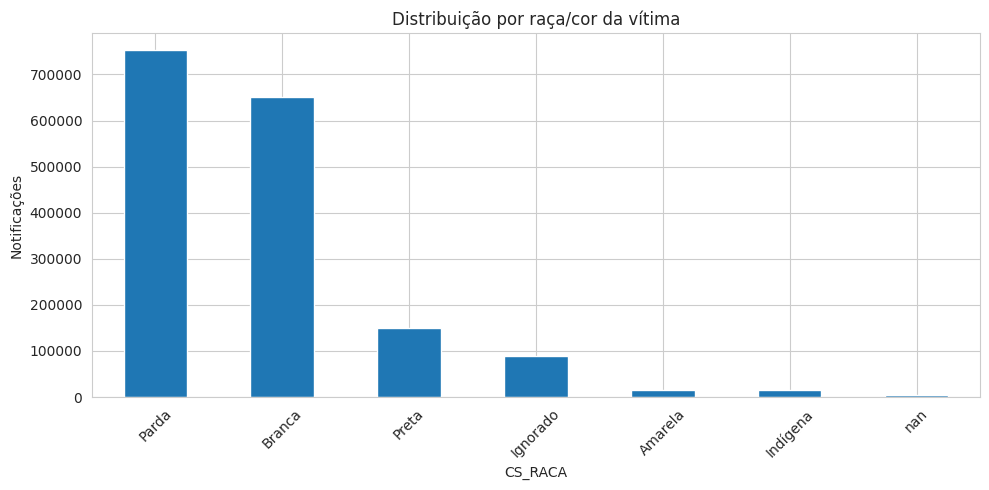

In [10]:
df['CS_RACA'].map(mapa_raca).value_counts(dropna=False).plot(kind='bar')
plt.title('Distribuição por raça/cor da vítima')
plt.ylabel('Notificações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.3 Escolaridade

In [11]:
mapa_escol = {
    '00': 'Analfabeto', '01': '1ª-4ª inc.', '02': '4ª completa',
    '03': '5ª-8ª inc.', '04': 'EF completo', '05': 'EM incompleto',
    '06': 'EM completo', '07': 'Sup. inc.', '08': 'Sup. completo',
    '09': 'Ignorado', '10': 'Não se aplica'
}
df['CS_ESCOL_N'].map(mapa_escol).value_counts(dropna=False)

,count
CS_ESCOL_N,
Ignorado,445320
EM completo,297036
5ª-8ª inc.,215203
EM incompleto,169442
Não se aplica,139616
EF completo,100612
1ª-4ª inc.,77166
NaN,66948
Sup. completo,59604


### 2.4 Gestação

In [12]:
mapa_gest = {'1': '1º Trim', '2': '2º Trim', '3': '3º Trim',
             '4': 'Idade gest. ign.', '5': 'Não', '6': 'N/A',
             '9': 'Ignorado'}
df['CS_GESTANT'].map(mapa_gest).value_counts(dropna=False)

,count
CS_GESTANT,
Não,1120679
N/A,257207
Ignorado,212817
1º Trim,34457
2º Trim,24656
3º Trim,21744
Idade gest. ign.,6316
NaN,12


---

# 3. Ocorrência

### 3.1 Notificações por ano

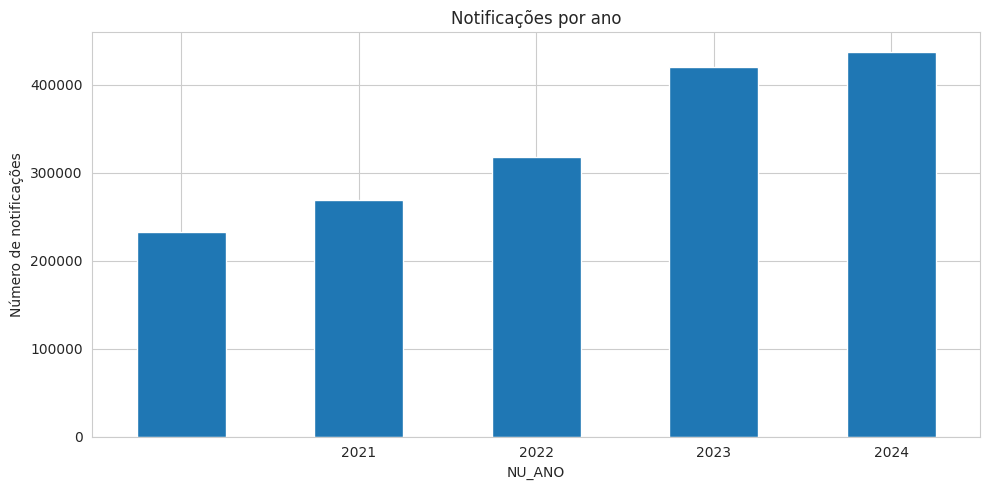

In [13]:
df['NU_ANO'].value_counts().sort_index().plot(kind='bar')
plt.title('Notificações por ano')
plt.ylabel('Número de notificações')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2 UF de notificação

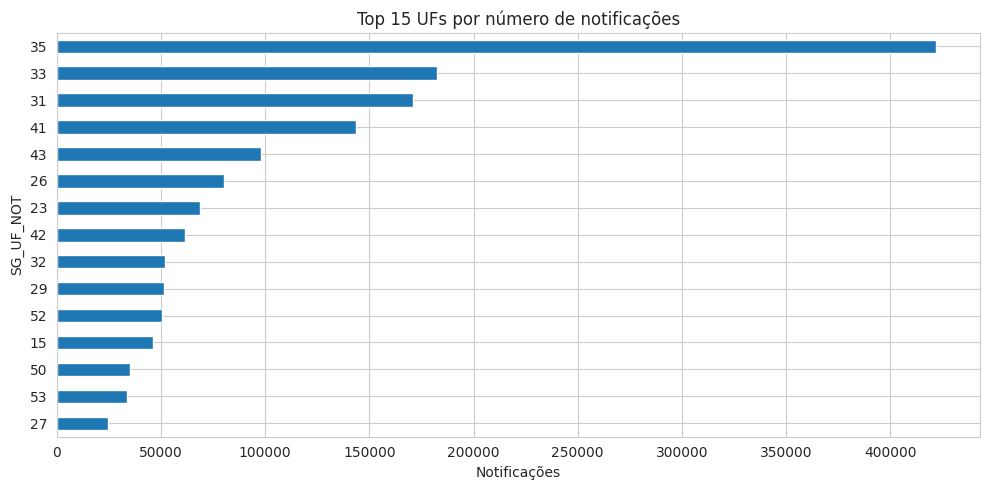

In [14]:
top_uf = df['SG_UF_NOT'].value_counts().head(15)
top_uf.plot(kind='barh')
plt.title('Top 15 UFs por número de notificações')
plt.xlabel('Notificações')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.3 Local de ocorrência

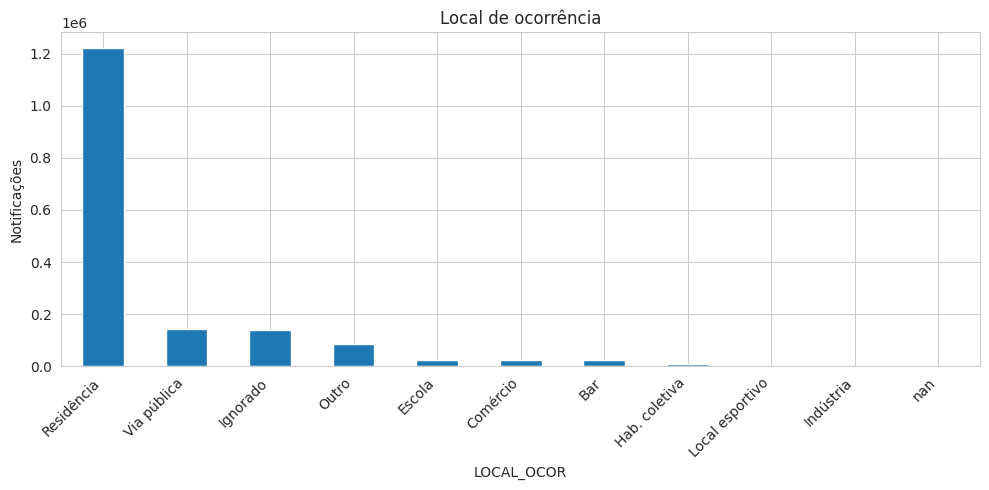

In [15]:
mapa_local = {
    '01': 'Residência', '02': 'Hab. coletiva', '03': 'Escola',
    '04': 'Local esportivo', '05': 'Bar', '06': 'Via pública',
    '07': 'Comércio', '08': 'Indústria', '09': 'Outro',
    '99': 'Ignorado'
}
df['LOCAL_OCOR'].map(mapa_local).value_counts(dropna=False).plot(kind='bar')
plt.title('Local de ocorrência')
plt.ylabel('Notificações')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.4 Reincidência

In [16]:
# OUT_VEZES: 1=Sim, 2=Não, 9=Ignorado
df['OUT_VEZES'].value_counts(dropna=False)

,count
OUT_VEZES,
1,742995
2,577211
9,341059
,16623


---

# 4. Tipos de violência

### 4.1 Distribuição dos 9 tipos

In [17]:
tipos = ['VIOL_FISIC', 'VIOL_PSICO', 'VIOL_TORT', 'VIOL_SEXU',
         'VIOL_TRAF', 'VIOL_FINAN', 'VIOL_NEGLI', 'VIOL_INFAN',
         'VIOL_LEGAL', 'VIOL_OUTR']

# % de Sim para cada tipo
prevalencias = {}
for t in tipos:
    if t in df.columns:
        sim = (df[t] == '1').sum()
        nao = (df[t] == '2').sum()
        ign = (df[t] == '9').sum() + df[t].isna().sum()
        prev = 100 * sim / (sim + nao) if (sim + nao) > 0 else 0
        prevalencias[t] = {'Sim': sim, 'Não': nao, 'Ign/NaN': ign, 'Prev (%)': round(prev, 1)}

prev_df = pd.DataFrame(prevalencias).T
prev_df

,Sim,Não,Ign/NaN,Prev (%)
VIOL_FISIC,827465.0,829018.0,14195.0,50.0
VIOL_PSICO,384248.0,1253661.0,25157.0,23.5
VIOL_TORT,32688.0,1598132.0,29060.0,2.0
VIOL_SEXU,271400.0,1365662.0,23808.0,16.6
VIOL_TRAF,742.0,1632337.0,26285.0,0.0
VIOL_FINAN,32327.0,1599717.0,27395.0,2.0
VIOL_NEGLI,139530.0,1502594.0,25783.0,8.5
VIOL_INFAN,3258.0,1629796.0,26321.0,0.2
VIOL_LEGAL,1730.0,1630208.0,27405.0,0.1
VIOL_OUTR,367798.0,1225657.0,66944.0,23.1


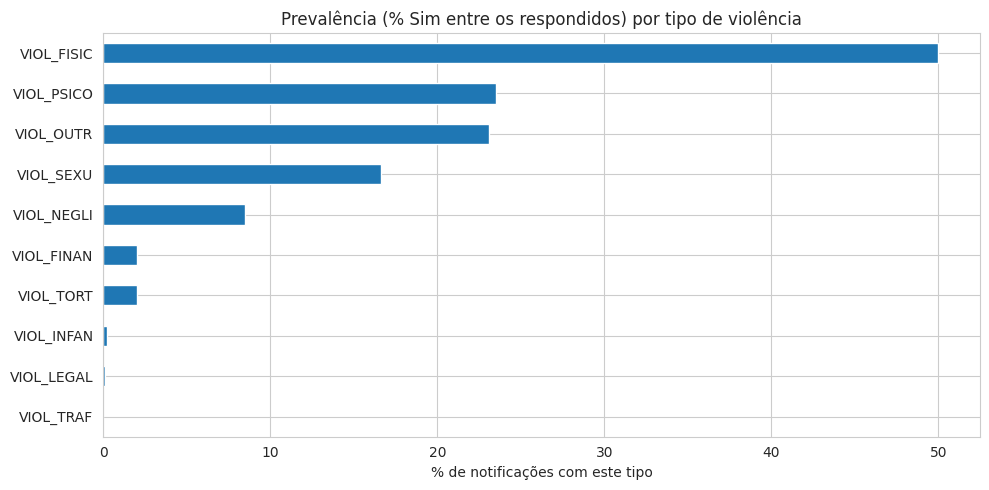

In [18]:
# Visualiza prevalências
prev_df['Prev (%)'].sort_values().plot(kind='barh')
plt.title('Prevalência (% Sim entre os respondidos) por tipo de violência')
plt.xlabel('% de notificações com este tipo')
plt.tight_layout()
plt.show()

### 4.3 Os 3 alvos do nosso projeto

In [20]:
for col in ['y_fisic', 'y_psico', 'y_sexu']:
    n_pos = (df[col] == 1).sum()
    n_neg = (df[col] == 0).sum()
    n_na = df[col].isna().sum()
    prev = 100 * n_pos / (n_pos + n_neg)
    print(f'{col}: Sim={n_pos:>7,} | Não={n_neg:>7,} | NaN={n_na:>7,} | Prevalência={prev:.1f}%')

y_fisic: Sim=827,465 | Não=829,018 | NaN= 21,405 | Prevalência=50.0%
y_psico: Sim=384,248 | Não=1,253,661 | NaN= 39,979 | Prevalência=23.5%
y_sexu: Sim=271,400 | Não=1,365,662 | NaN= 40,826 | Prevalência=16.6%


---

# 5. Agressor

### 5.1 Sexo do agressor

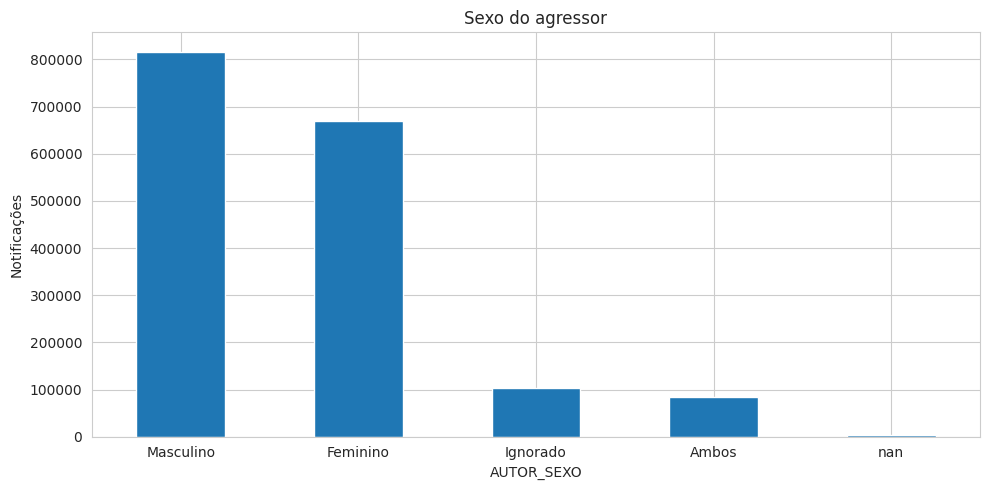

In [21]:
mapa_sexo_aut = {'1': 'Masculino', '2': 'Feminino',
                  '3': 'Ambos', '9': 'Ignorado'}
df['AUTOR_SEXO'].map(mapa_sexo_aut).value_counts(dropna=False).plot(kind='bar')
plt.title('Sexo do agressor')
plt.ylabel('Notificações')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Suspeita de uso de álcool pelo agressor

In [22]:
mapa_alco = {'1': 'Sim', '2': 'Não', '9': 'Ignorado'}
df['AUTOR_ALCO'].map(mapa_alco).value_counts(dropna=False)

,count
AUTOR_ALCO,
Não,791504
Ignorado,477274
Sim,389407
NaN,19703


### 5.3 Relação com agressor — frequência de cada tipo

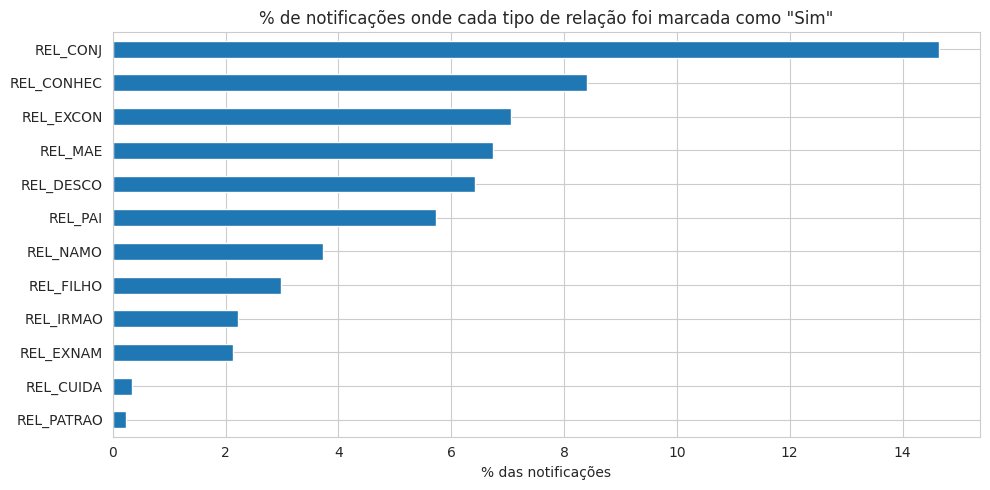

In [23]:
rels = ['REL_PAI', 'REL_MAE', 'REL_CONJ', 'REL_EXCON', 'REL_NAMO',
        'REL_EXNAM', 'REL_FILHO', 'REL_IRMAO',
        'REL_CONHEC', 'REL_DESCO', 'REL_CUIDA', 'REL_PATRAO']

# % de "Sim" em cada relação
freq_rel = {r: (df[r] == '1').mean() * 100 for r in rels if r in df.columns}
freq_rel = pd.Series(freq_rel).sort_values()

freq_rel.plot(kind='barh')
plt.title('% de notificações onde cada tipo de relação foi marcada como "Sim"')
plt.xlabel('% das notificações')
plt.tight_layout()
plt.show()

---

# 6. Síntese — problemas identificados

Após percorrer a EDA, anote aqui (em markdown) o que precisará ser tratado no próximo notebook:

**Tipos de problema esperados:**
- Idades fora do plausível (>110, negativas)
- Colunas com >X% de NaN — descartar?
- Códigos `'9'` (Ignorado) que precisam decidir: virar NaN ou virar categoria?
- Possíveis duplicatas
- Inconsistências (datas impossíveis, etc.)

**Decisões de recorte:**
- Manter crianças (0-9)? OMS define adolescente a partir de 10 anos.
- Manter casos com sexo do agressor "Ignorado"?
- O quê fazer com casos onde o alvo é NaN?

In [ ]:
# Espaço para suas anotações enquanto roda a EDA
# (vai preenchendo conforme descobre coisas)